# UK Economy analysis

## Focus on:
1. How have inflation, GDP, unemployment, and wages changed over time? What might have been the reason for this?
2. Is there a lag between interest rates and inflation?
3. How is unemployment linked to inflation?
4. Compare the 2008 Financial Crisis and COVID-19 by analysing their impacts on GDP, unemployment, inflation, and wages.

In this section, I import the datasets into Python and examine their basic structure. I review the number of observations and variables, inspect the first few rows of each dataset, and identify the parameters that are most relevant to the objectives of this project.

## Data Import and Initial Data Inspection

In [1]:
# Importing some of the relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime  # Import the datetime module

In [2]:
# Importing and visualising the files
bank_rate = pd.read_csv('Bank_Rate_history_and_data _Bank_of_England_Database.csv')

gdp_monthly = pd.read_csv('Monthly_gross_domestic_product_time series.csv')

unemployment_rate = pd.read_csv('unemployment_rate_seasonally_adjusted_percentage.csv')

inflation = pd.read_csv('Consumer_price_inflation_time_series.csv')

C:\Users\Rafi\AppData\Local\Temp\ipykernel_5420\4058105013.py:8: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,

In [3]:
# The consumer price index file has the issue where a single column contains mixed data types and Pandas is unable to read this correctly. Also, the file has 4000+ columns of data. Python to save memory is trying to read only smaller chunks of data
# To seolve this, we can read the whole file and since my PC's specs are good enough, it should be able to read the file without any issues
inflation = pd.read_csv('Consumer_price_inflation_time_series.csv', low_memory=False)

In [4]:
# Now going to check the size of these files - How many rows of data
size_bank_rate = len(bank_rate) 
size_gdp_monthly = len(gdp_monthly)  
size_unemployment_rate = len(unemployment_rate)
size_inflation = len(inflation)

# Printing their size
print(f'Bank rate file rows: {size_bank_rate}', f'GDP file rows: {size_gdp_monthly}', f'unemployment file rows: {size_unemployment_rate}',
      f'Consumer Price Index file rows: {size_inflation}', sep='\n')

Bank rate file rows: 258
GDP file rows: 358
unemployment file rows: 945
Consumer Price Index file rows: 1492


The output above shows the number of rows in each dataset. I am also interested in determining the number of columns (parameters) in each file, as this will help assess the range of available variables and decide which ones should be included in the analysis if there are too many.

In [5]:
# Now going to check the number of columns of these files
print(f'Bank rate file columns: {bank_rate.shape[1]}', f'GDP file columns: {gdp_monthly.shape[1]}', f'unemployment file columns: {unemployment_rate.shape[1]}',
      f'Consumer Price Index file columns: {inflation.shape[1]}', sep='\n')

Bank rate file columns: 2
GDP file columns: 208
unemployment file columns: 2
Consumer Price Index file columns: 4054


As shown above, the Bank Rate and unemployment datasets each contain only two columns, whereas the CPI and GDP datasets consist of multiple parameters. The next step is to examine these parameters to determine which are relevant to the objectives of this project. Only the variables that contribute to answering the research questions will be retained, while the remaining ones will be excluded from the analysis.

In [6]:
# In the next step, I want to convert these files into DataFrame format which is make it easier for data manipulation as it will organise it into tabular form
# Creating and visualising bank rate dataframe
bank_rate_df = pd.DataFrame(bank_rate)
bank_rate_df

,Date Changed,Rate
0,18 Dec 25,3.75
1,07 Aug 25,4.00
2,08 May 25,4.25
3,06 Feb 25,4.50
4,07 Nov 24,4.75
...,...,...
253,10 Mar 75,10.25
254,17 Feb 75,10.50
255,10 Feb 75,10.75
256,27 Jan 75,11.00


In [7]:
# Creating and visualising GDP dataframe
gdp_monthly_df = pd.DataFrame(gdp_monthly)
gdp_monthly_df

,Title,Gross Value Added - Monthly (Index 1dp) :CVM SA,"Agriculture, Forestry and Fishing (Index 1dp) :CVM SA",Production Industries - Total (Index 1dp) :CVM SA,Mining and Quarrying (Index 1dp) :CVM SA,Manufacturing (Index 1dp) :CVM SA,"Electricity, gas, steam and air conditioning supply(Index 1dp) :CVM SA","Water supply; Sewerage,waste management & remediation activities (Index 1dp) :CVM SA",Construction (Index 1dp) :CVM SA,Service Industries - Total (Index 1dp) :CVM SA,...,Financial and insurance activities (3m on 3m 1 year ago contribution) :CVM SA,Real estate activities (3m on 3m 1 year ago contribution) :CVM SA,"Professional, scientific and technical activities (3m on 3m 1 year ago contribution) :CVM SA",Administrative and Support Service Activities (3m on 3m 1 year ago contribution) :CVM SA,Public admin and defence; Compulsory social security (3m on 3m 1 year ago contribution) :CVM SA,Education (3m on 3m 1 year ago contribution) :CVM SA,Human health and social work activities (3m on 3m 1 year ago contribution) :CVM SA,"Arts, Entertainment and Recreation (3m on 3m 1 year ago contribution) :CVM SA",Other service activities (3m on 3m 1 year ago contribution) :CVM SA,Activities of housholds as employers;Undiff goods & services (3m on 3m 1 year ago contribution) :CVM SA
0,CDID,ECY2,ECY3,ECY4,ECY5,ECY6,ECY7,ECY8,ECY9,ECYC,...,EDNL,EDNM,EDNN,EDNO,EDNP,EDNQ,EDNR,EDNS,EDNT,EDNU
1,PreUnit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Unit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Release Date,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,...,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026
4,Next release,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,...,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,2025 DEC,102.6,101.2,98.8,86.4,100.0,97.6,104.1,97.9,103.6,...,0.12,0.08,-0.21,0.13,0.12,-0.05,0.20,0.06,0.03,-0.01
354,2026 JAN,102.7,99.4,98.6,81.8,100.1,98.2,105.5,98.6,103.7,...,0.12,0.07,-0.19,0.04,0.11,-0.01,0.18,0.04,0.01,-0.01
355,2026 FEB,103.1,98.1,98.9,85.1,99.9,99.1,105.4,99.1,104.1,...,0.13,0.08,-0.15,-0.02,0.09,0.03,0.18,0.01,0.04,0.00
356,2026 MAR,103.4,97.0,98.7,83.1,101.1,94.8,103.7,100.6,104.5,...,0.15,0.10,-0.10,-0.03,0.07,0.06,0.20,0.02,0.05,0.00


In [8]:
# Creating and visualising unemployment dataframe
unemployment_rate_df = pd.DataFrame(unemployment_rate)
unemployment_rate_df

,Title,"Unemployment rate (aged 16 and over, seasonally adjusted): %"
0,CDID,MGSX
1,Source dataset ID,LMS
2,PreUnit,NaN
3,Unit,%
4,Release date,18-06-2026
...,...,...
940,2025 NOV,5.2
941,2025 DEC,5.2
942,2026 JAN,4.9
943,2026 FEB,5.0


In [9]:
# Creating and visualising CPI dataframe
inflation_df = pd.DataFrame(inflation)
inflation_df

,Title,CPI wts: Non-energy industrial goods GOODS,CPI wts: Durables GOODS,CPI wts: Semi-durables GOODS,CPI wts: Non-durables GOODS,CPI wts: Non-seasonal food GOODS,"CPI wts: Food, alcoholic beverages & tobacco GOODS",CPI wts: Processed food & non-alcoholic beverages GOODS,CPI wts: Unprocessed food GOODS,CPI wts: Seasonal food GOODS,...,CPI: % points change over previous month (12 month rate): Furniture & hhold good,CPI: % points change over previous month (12 month rate): Health,CPI: % points change over previous month (12 month rate): Transport,CPI: % points change over previous month (12 month rate): Communication,CPI: % points change over previous month (12 month rate): Recreation & culture,CPI: % points change over previous month (12 month rate): Education,CPI: % points change over previous month (12 month rate): Restaurants & hotels,CPI: % points change over previous month (12 month rate): Misc goods & services,Internal purchasing power of the pound (based on RPI): 2000 = 100,"RPI: Ave price - Salmon fillets, per Kg"
0,CDID,A9ER,A9ES,A9ET,A9EU,A9EV,A9EW,A9EX,A9EY,A9EZ,...,WUNQ,WUNZ,WUOA,WUOO,WUOP,WUOU,WUOV,WUOW,ZMHO,ZPTX
1,PreUnit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Unit,Parts per 1000,Parts per 1000,Parts per 1000,Parts per 1000,Parts per 1000,Parts per 1000,Parts per 1000,Parts per 1000,Parts per 1000,...,%,%,%,%,%,%,%,%,Pence,Pence
3,Release Date,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,...,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026
4,Next release,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,...,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487,2026 JAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.01,0.03,-0.19,0.01,-0.01,-0.07,0.03,0.00,NaN,NaN
1488,2026 FEB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.03,0.00,-0.04,-0.01,-0.02,0.00,-0.01,0.03,NaN,NaN
1489,2026 MAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.03,0.00,0.33,0.00,0.04,0.00,0.00,-0.01,NaN,NaN
1490,2026 APR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.06,-0.02,0.02,0.01,-0.15,0.00,0.06,0.01,NaN,NaN


The inflation and GDP datasets contain many parameters and indicators. However, for the purposes of this project, I will select only the variables that are relevant and useful for answering the project's main research questions.

Another observation I made is that the inflation dataset contains a large number of NaN values, which will need to be addressed before the analysis can begin. Additionally, all datasets except the bank rate dataset include several initial rows containing metadata rather than actual observations. The next step is to examine these datasets thoroughly to identify the necessary preprocessing steps before loading them into a database.

## Data Cleaning and Transformation

### Consumer Price Index - inflation Data

Before writing any data cleaning code, I opened the raw CSV file to understand its structure. I found that the file contains annual, quarterly, and monthly data combined within a single date column, preceded by six rows of metadata (e.g., CDID, units, release dates, and notes). Inspecting the raw file first allowed me to determine the most appropriate cleaning strategy, which is explained in detail later in this section.

The main data cleaning steps for the inflation dataset are as follows:

1. Remove the metadata rows (rows 2–7). These rows contain metadata rather than observations and include information such as CDID, PreUnit, Unit, Release Date, Next Release, and Important Notes.

2. Separate the data by reporting frequency. The annual, quarterly, and monthly observations will be stored in separate variables, with the monthly data being the primary focus of this project.

3. Select the relevant variables. The dataset contains 4,054 columns, many of which are not required for this analysis. I will identify and retain only the variables that are relevant to the project's research objectives.

A screenshot of the inflation CSV is attached below for more information.
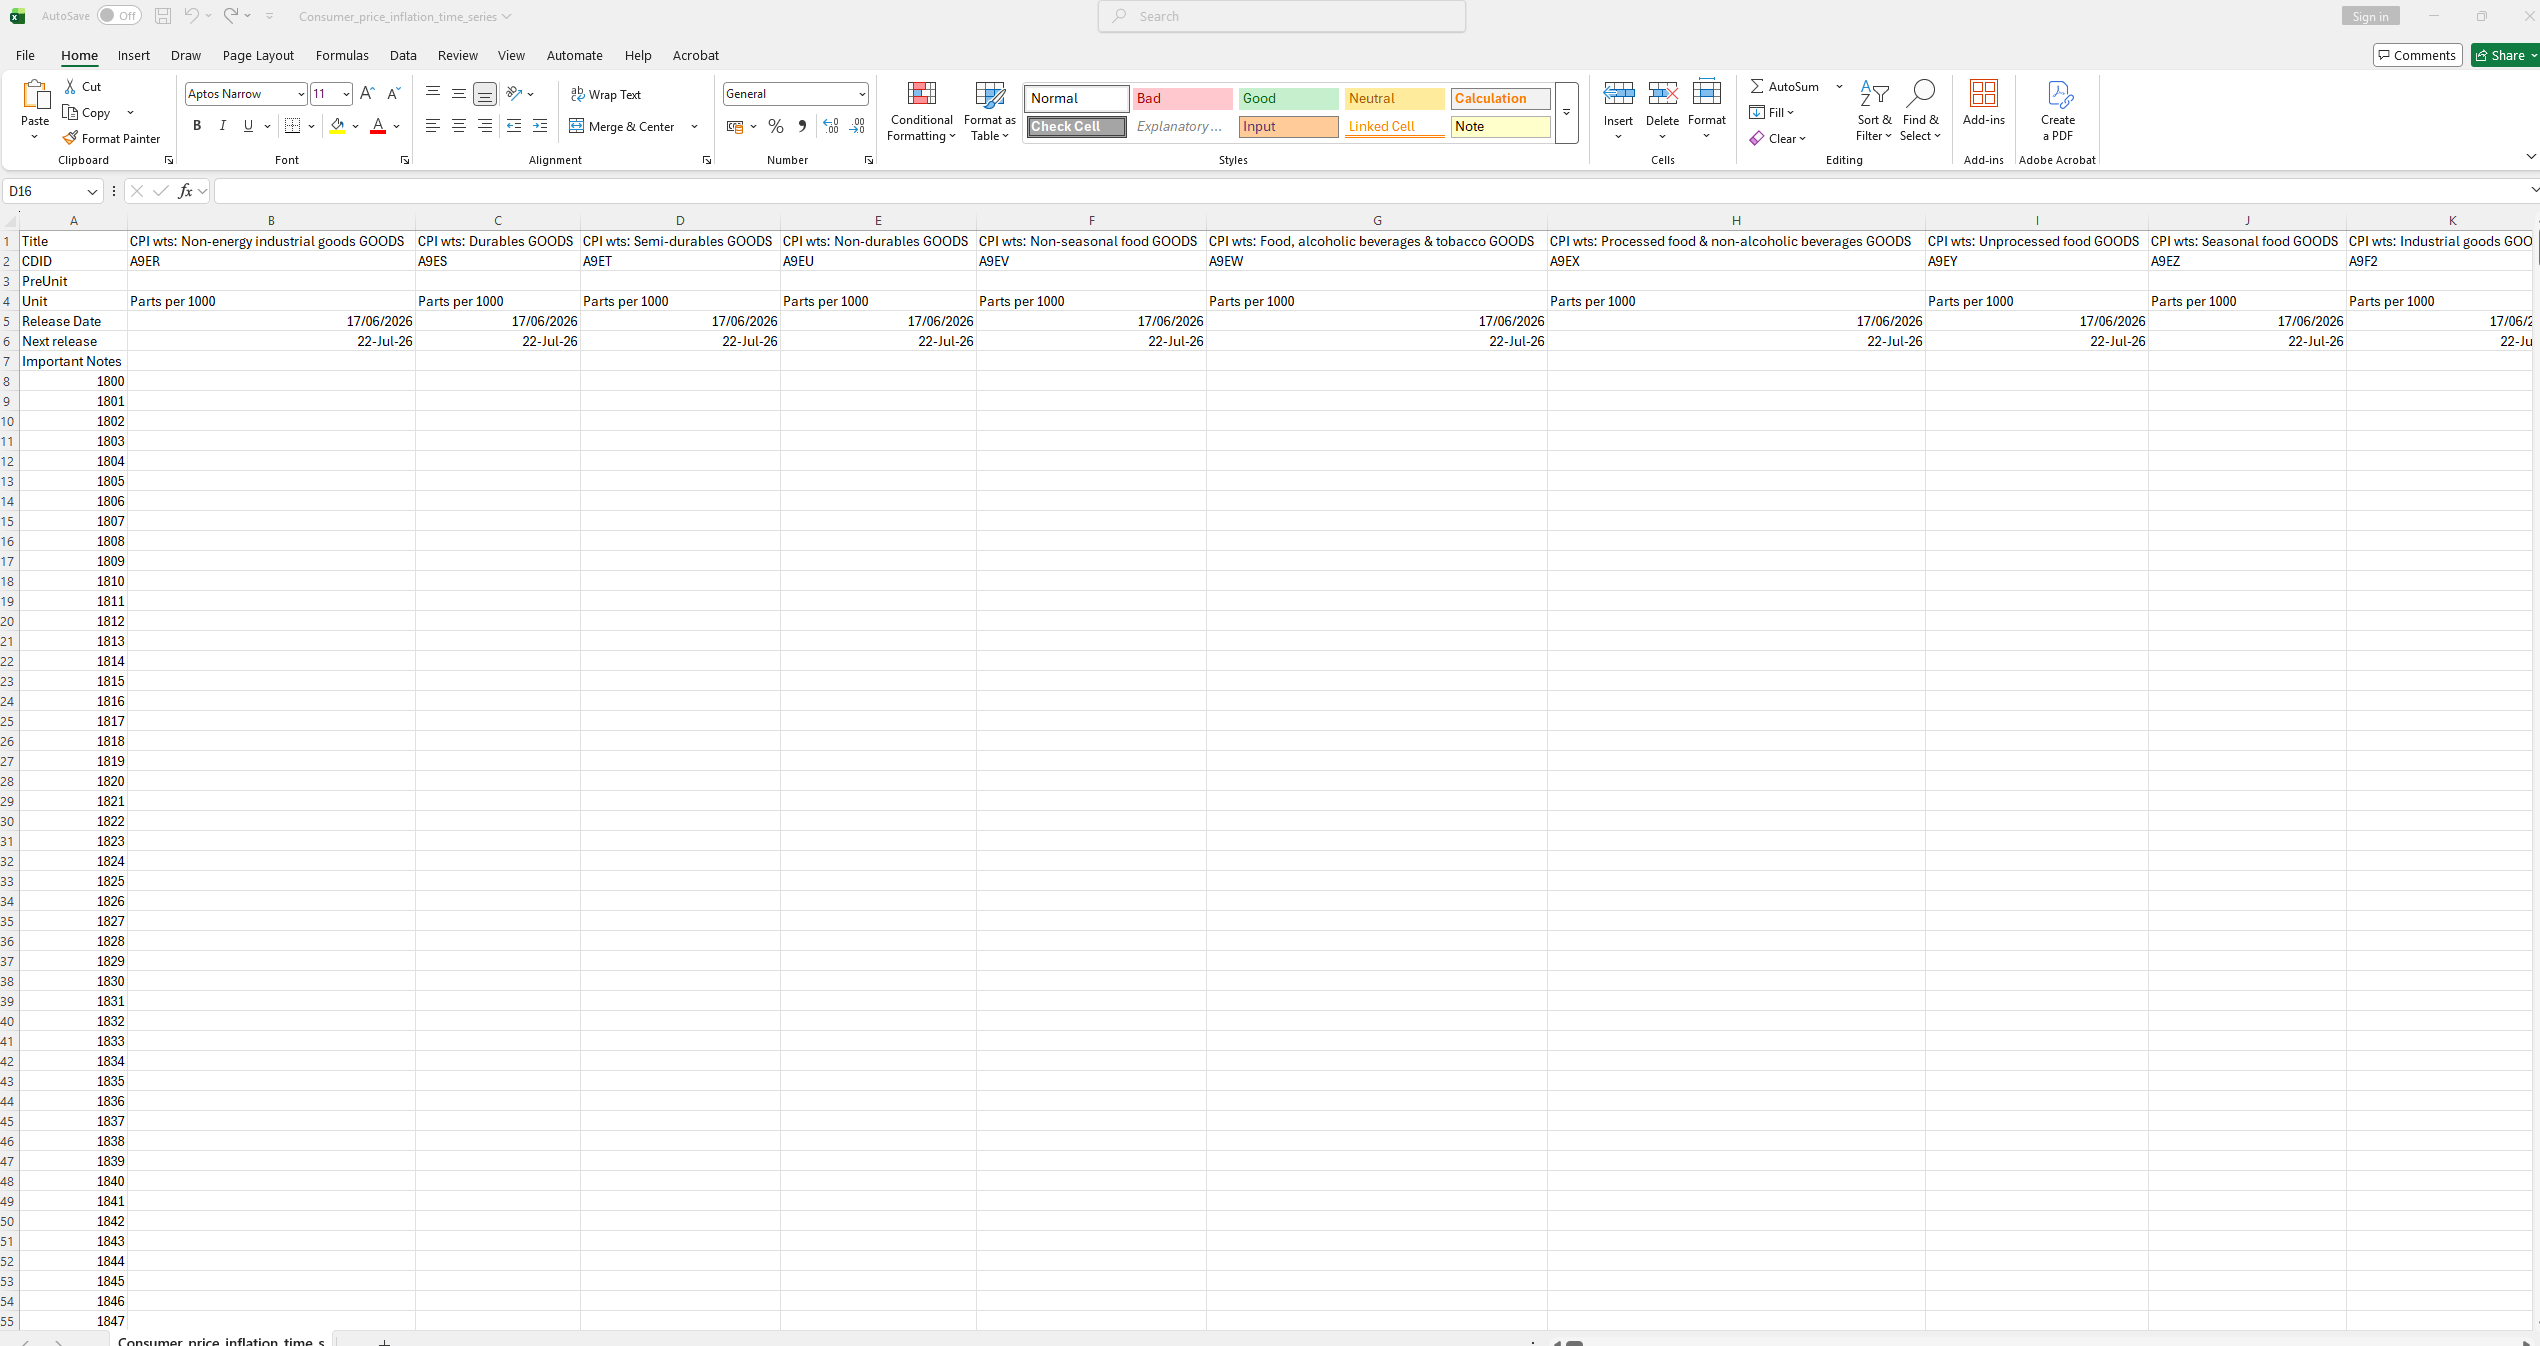

In [10]:
# Let's first see how the DataFrame looks first
inflation_df

,Title,CPI wts: Non-energy industrial goods GOODS,CPI wts: Durables GOODS,CPI wts: Semi-durables GOODS,CPI wts: Non-durables GOODS,CPI wts: Non-seasonal food GOODS,"CPI wts: Food, alcoholic beverages & tobacco GOODS",CPI wts: Processed food & non-alcoholic beverages GOODS,CPI wts: Unprocessed food GOODS,CPI wts: Seasonal food GOODS,...,CPI: % points change over previous month (12 month rate): Furniture & hhold good,CPI: % points change over previous month (12 month rate): Health,CPI: % points change over previous month (12 month rate): Transport,CPI: % points change over previous month (12 month rate): Communication,CPI: % points change over previous month (12 month rate): Recreation & culture,CPI: % points change over previous month (12 month rate): Education,CPI: % points change over previous month (12 month rate): Restaurants & hotels,CPI: % points change over previous month (12 month rate): Misc goods & services,Internal purchasing power of the pound (based on RPI): 2000 = 100,"RPI: Ave price - Salmon fillets, per Kg"
0,CDID,A9ER,A9ES,A9ET,A9EU,A9EV,A9EW,A9EX,A9EY,A9EZ,...,WUNQ,WUNZ,WUOA,WUOO,WUOP,WUOU,WUOV,WUOW,ZMHO,ZPTX
1,PreUnit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Unit,Parts per 1000,Parts per 1000,Parts per 1000,Parts per 1000,Parts per 1000,Parts per 1000,Parts per 1000,Parts per 1000,Parts per 1000,...,%,%,%,%,%,%,%,%,Pence,Pence
3,Release Date,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,...,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026,17-06-2026
4,Next release,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,...,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026,22 July 2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487,2026 JAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.01,0.03,-0.19,0.01,-0.01,-0.07,0.03,0.00,NaN,NaN
1488,2026 FEB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.03,0.00,-0.04,-0.01,-0.02,0.00,-0.01,0.03,NaN,NaN
1489,2026 MAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.03,0.00,0.33,0.00,0.04,0.00,0.00,-0.01,NaN,NaN
1490,2026 APR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.06,-0.02,0.02,0.01,-0.15,0.00,0.06,0.01,NaN,NaN


In [11]:
# Dropping the metadata lines
inflation_df_filtered = inflation_df.drop(range(0,7))
inflation_df_filtered

,Title,CPI wts: Non-energy industrial goods GOODS,CPI wts: Durables GOODS,CPI wts: Semi-durables GOODS,CPI wts: Non-durables GOODS,CPI wts: Non-seasonal food GOODS,"CPI wts: Food, alcoholic beverages & tobacco GOODS",CPI wts: Processed food & non-alcoholic beverages GOODS,CPI wts: Unprocessed food GOODS,CPI wts: Seasonal food GOODS,...,CPI: % points change over previous month (12 month rate): Furniture & hhold good,CPI: % points change over previous month (12 month rate): Health,CPI: % points change over previous month (12 month rate): Transport,CPI: % points change over previous month (12 month rate): Communication,CPI: % points change over previous month (12 month rate): Recreation & culture,CPI: % points change over previous month (12 month rate): Education,CPI: % points change over previous month (12 month rate): Restaurants & hotels,CPI: % points change over previous month (12 month rate): Misc goods & services,Internal purchasing power of the pound (based on RPI): 2000 = 100,"RPI: Ave price - Salmon fillets, per Kg"
7,1801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,1804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,1805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487,2026 JAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.01,0.03,-0.19,0.01,-0.01,-0.07,0.03,0.00,NaN,NaN
1488,2026 FEB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.03,0.00,-0.04,-0.01,-0.02,0.00,-0.01,0.03,NaN,NaN
1489,2026 MAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.03,0.00,0.33,0.00,0.04,0.00,0.00,-0.01,NaN,NaN
1490,2026 APR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.06,-0.02,0.02,0.01,-0.15,0.00,0.06,0.01,NaN,NaN


In [12]:
# I want to re-set the index to make it look better and renaming the "Title" column into "Frequency"
inflation_df_filtered.reset_index(inplace=True)
inflation_df_filtered = inflation_df_filtered.loc[:, inflation_df_filtered.columns != 'index'] # This is to remove a column "index" which gets generated once you reset this
inflation_df_filtered = inflation_df_filtered.rename(columns={'Title':'Frequency'}) # Renaming the first column into a more descriptive one for the case
inflation_df_filtered.head(10)

,Frequency,CPI wts: Non-energy industrial goods GOODS,CPI wts: Durables GOODS,CPI wts: Semi-durables GOODS,CPI wts: Non-durables GOODS,CPI wts: Non-seasonal food GOODS,"CPI wts: Food, alcoholic beverages & tobacco GOODS",CPI wts: Processed food & non-alcoholic beverages GOODS,CPI wts: Unprocessed food GOODS,CPI wts: Seasonal food GOODS,...,CPI: % points change over previous month (12 month rate): Furniture & hhold good,CPI: % points change over previous month (12 month rate): Health,CPI: % points change over previous month (12 month rate): Transport,CPI: % points change over previous month (12 month rate): Communication,CPI: % points change over previous month (12 month rate): Recreation & culture,CPI: % points change over previous month (12 month rate): Education,CPI: % points change over previous month (12 month rate): Restaurants & hotels,CPI: % points change over previous month (12 month rate): Misc goods & services,Internal purchasing power of the pound (based on RPI): 2000 = 100,"RPI: Ave price - Salmon fillets, per Kg"
0,1801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Now, I want to save the yearly, queterly and monthly data in 3 separate variables - Note: I know this because I reviewed the CSV file directly
inflation_yearly_df = inflation_df_filtered.iloc[0:226]
inflation_quarterly_df = inflation_df_filtered.iloc[226:537]
inflation_monthly_df = inflation_df_filtered.iloc[537:]

In [14]:
# Checking if yearly data is correct
inflation_yearly_df

,Frequency,CPI wts: Non-energy industrial goods GOODS,CPI wts: Durables GOODS,CPI wts: Semi-durables GOODS,CPI wts: Non-durables GOODS,CPI wts: Non-seasonal food GOODS,"CPI wts: Food, alcoholic beverages & tobacco GOODS",CPI wts: Processed food & non-alcoholic beverages GOODS,CPI wts: Unprocessed food GOODS,CPI wts: Seasonal food GOODS,...,CPI: % points change over previous month (12 month rate): Furniture & hhold good,CPI: % points change over previous month (12 month rate): Health,CPI: % points change over previous month (12 month rate): Transport,CPI: % points change over previous month (12 month rate): Communication,CPI: % points change over previous month (12 month rate): Recreation & culture,CPI: % points change over previous month (12 month rate): Education,CPI: % points change over previous month (12 month rate): Restaurants & hotels,CPI: % points change over previous month (12 month rate): Misc goods & services,Internal purchasing power of the pound (based on RPI): 2000 = 100,"RPI: Ave price - Salmon fillets, per Kg"
0,1801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,2022,330.0000,130.0000,120.0000,80.0000,73.0000,166.0000,64.0000,52.0000,32.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1738
222,2023,293.0000,113.0000,109.0000,71.0000,77.0000,161.0000,69.0000,50.0000,30.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1952
223,2024,285.8694,103.4408,108.7981,73.6306,73.0425,152.2960,64.7060,48.4404,28.3786,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1978
224,2025,286.3633,99.8503,113.1087,73.4043,71.9127,151.1486,64.8411,47.7288,28.7083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Checking if quaterly data is correct
inflation_quarterly_df

,Frequency,CPI wts: Non-energy industrial goods GOODS,CPI wts: Durables GOODS,CPI wts: Semi-durables GOODS,CPI wts: Non-durables GOODS,CPI wts: Non-seasonal food GOODS,"CPI wts: Food, alcoholic beverages & tobacco GOODS",CPI wts: Processed food & non-alcoholic beverages GOODS,CPI wts: Unprocessed food GOODS,CPI wts: Seasonal food GOODS,...,CPI: % points change over previous month (12 month rate): Furniture & hhold good,CPI: % points change over previous month (12 month rate): Health,CPI: % points change over previous month (12 month rate): Transport,CPI: % points change over previous month (12 month rate): Communication,CPI: % points change over previous month (12 month rate): Recreation & culture,CPI: % points change over previous month (12 month rate): Education,CPI: % points change over previous month (12 month rate): Restaurants & hotels,CPI: % points change over previous month (12 month rate): Misc goods & services,Internal purchasing power of the pound (based on RPI): 2000 = 100,"RPI: Ave price - Salmon fillets, per Kg"
226,1948 Q3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
227,1948 Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
228,1949 Q1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
229,1949 Q2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
230,1949 Q3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532,2025 Q1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
533,2025 Q2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
534,2025 Q3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
535,2025 Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Checking if monthly data is correct
inflation_monthly_df

,Frequency,CPI wts: Non-energy industrial goods GOODS,CPI wts: Durables GOODS,CPI wts: Semi-durables GOODS,CPI wts: Non-durables GOODS,CPI wts: Non-seasonal food GOODS,"CPI wts: Food, alcoholic beverages & tobacco GOODS",CPI wts: Processed food & non-alcoholic beverages GOODS,CPI wts: Unprocessed food GOODS,CPI wts: Seasonal food GOODS,...,CPI: % points change over previous month (12 month rate): Furniture & hhold good,CPI: % points change over previous month (12 month rate): Health,CPI: % points change over previous month (12 month rate): Transport,CPI: % points change over previous month (12 month rate): Communication,CPI: % points change over previous month (12 month rate): Recreation & culture,CPI: % points change over previous month (12 month rate): Education,CPI: % points change over previous month (12 month rate): Restaurants & hotels,CPI: % points change over previous month (12 month rate): Misc goods & services,Internal purchasing power of the pound (based on RPI): 2000 = 100,"RPI: Ave price - Salmon fillets, per Kg"
537,1947 JUN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
538,1947 JUL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539,1947 AUG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
540,1947 SEP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
541,1947 OCT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1480,2026 JAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.01,0.03,-0.19,0.01,-0.01,-0.07,0.03,0.00,NaN,NaN
1481,2026 FEB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.03,0.00,-0.04,-0.01,-0.02,0.00,-0.01,0.03,NaN,NaN
1482,2026 MAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.03,0.00,0.33,0.00,0.04,0.00,0.00,-0.01,NaN,NaN
1483,2026 APR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.06,-0.02,0.02,0.01,-0.15,0.00,0.06,0.01,NaN,NaN


While looking if there was a better way to perform what done above, I learned about regular expression.
This method looks for a specific patter in the data instead of fixed value (when using .iloc). This method is much better because if next year more data is released by the ONS and I were to update this file with RegEx I do not need to update the code while with .iloc I do as the whole table shifts because of the new data.

Quite an interesting thing to learn and add to my knowledge bank.

In [17]:
# Using Regex for monthly data
monthly_inflation_regex = inflation_df_filtered['Frequency'].astype(str).str.match(r'^\d{4} [A-Z]{3}$')
monthly_inflation_regex_df = inflation_df_filtered[monthly_inflation_regex]
monthly_inflation_regex_df

,Frequency,CPI wts: Non-energy industrial goods GOODS,CPI wts: Durables GOODS,CPI wts: Semi-durables GOODS,CPI wts: Non-durables GOODS,CPI wts: Non-seasonal food GOODS,"CPI wts: Food, alcoholic beverages & tobacco GOODS",CPI wts: Processed food & non-alcoholic beverages GOODS,CPI wts: Unprocessed food GOODS,CPI wts: Seasonal food GOODS,...,CPI: % points change over previous month (12 month rate): Furniture & hhold good,CPI: % points change over previous month (12 month rate): Health,CPI: % points change over previous month (12 month rate): Transport,CPI: % points change over previous month (12 month rate): Communication,CPI: % points change over previous month (12 month rate): Recreation & culture,CPI: % points change over previous month (12 month rate): Education,CPI: % points change over previous month (12 month rate): Restaurants & hotels,CPI: % points change over previous month (12 month rate): Misc goods & services,Internal purchasing power of the pound (based on RPI): 2000 = 100,"RPI: Ave price - Salmon fillets, per Kg"
537,1947 JUN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
538,1947 JUL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539,1947 AUG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
540,1947 SEP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
541,1947 OCT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1480,2026 JAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.01,0.03,-0.19,0.01,-0.01,-0.07,0.03,0.00,NaN,NaN
1481,2026 FEB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.03,0.00,-0.04,-0.01,-0.02,0.00,-0.01,0.03,NaN,NaN
1482,2026 MAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.03,0.00,0.33,0.00,0.04,0.00,0.00,-0.01,NaN,NaN
1483,2026 APR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.06,-0.02,0.02,0.01,-0.15,0.00,0.06,0.01,NaN,NaN


##### Code Explanation of `r'^\d{4} [A-Z]{3}$'`

1. **`^`** – Represents the start of the string.
2. **`$`** – Represents the end of the string.
3. **`\d{4}`** – Matches exactly four digits.
4. **`[A-Z]{3}`** – Matches exactly three uppercase letters.

In [18]:
# Using RegEx adapted for yearly data
yearly_inflation_regex = inflation_df_filtered['Frequency'].astype(str).str.match(r'^\d{4}$') # Since I am only interested in 4 digits, this will be enough to get the data
yearly_inflation_regex_df = inflation_df_filtered[yearly_inflation_regex]
yearly_inflation_regex_df

,Frequency,CPI wts: Non-energy industrial goods GOODS,CPI wts: Durables GOODS,CPI wts: Semi-durables GOODS,CPI wts: Non-durables GOODS,CPI wts: Non-seasonal food GOODS,"CPI wts: Food, alcoholic beverages & tobacco GOODS",CPI wts: Processed food & non-alcoholic beverages GOODS,CPI wts: Unprocessed food GOODS,CPI wts: Seasonal food GOODS,...,CPI: % points change over previous month (12 month rate): Furniture & hhold good,CPI: % points change over previous month (12 month rate): Health,CPI: % points change over previous month (12 month rate): Transport,CPI: % points change over previous month (12 month rate): Communication,CPI: % points change over previous month (12 month rate): Recreation & culture,CPI: % points change over previous month (12 month rate): Education,CPI: % points change over previous month (12 month rate): Restaurants & hotels,CPI: % points change over previous month (12 month rate): Misc goods & services,Internal purchasing power of the pound (based on RPI): 2000 = 100,"RPI: Ave price - Salmon fillets, per Kg"
0,1801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,2022,330.0000,130.0000,120.0000,80.0000,73.0000,166.0000,64.0000,52.0000,32.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1738
222,2023,293.0000,113.0000,109.0000,71.0000,77.0000,161.0000,69.0000,50.0000,30.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1952
223,2024,285.8694,103.4408,108.7981,73.6306,73.0425,152.2960,64.7060,48.4404,28.3786,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1978
224,2025,286.3633,99.8503,113.1087,73.4043,71.9127,151.1486,64.8411,47.7288,28.7083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# Using RegEx adapted for quaterly data
quaterly_inflation_regex = inflation_df_filtered['Frequency'].astype(str).str.match(r'^\d{4} [A-Z]{1}\d{1}$') # Applying the rule for 4 digits (\d{4}), then a space and then one upper case letter and a digit
quaterly_inflation_regex_df = inflation_df_filtered[quaterly_inflation_regex]
quaterly_inflation_regex_df

,Frequency,CPI wts: Non-energy industrial goods GOODS,CPI wts: Durables GOODS,CPI wts: Semi-durables GOODS,CPI wts: Non-durables GOODS,CPI wts: Non-seasonal food GOODS,"CPI wts: Food, alcoholic beverages & tobacco GOODS",CPI wts: Processed food & non-alcoholic beverages GOODS,CPI wts: Unprocessed food GOODS,CPI wts: Seasonal food GOODS,...,CPI: % points change over previous month (12 month rate): Furniture & hhold good,CPI: % points change over previous month (12 month rate): Health,CPI: % points change over previous month (12 month rate): Transport,CPI: % points change over previous month (12 month rate): Communication,CPI: % points change over previous month (12 month rate): Recreation & culture,CPI: % points change over previous month (12 month rate): Education,CPI: % points change over previous month (12 month rate): Restaurants & hotels,CPI: % points change over previous month (12 month rate): Misc goods & services,Internal purchasing power of the pound (based on RPI): 2000 = 100,"RPI: Ave price - Salmon fillets, per Kg"
226,1948 Q3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
227,1948 Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
228,1949 Q1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
229,1949 Q2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
230,1949 Q3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532,2025 Q1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
533,2025 Q2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
534,2025 Q3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
535,2025 Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Now that I have segmented the Inflation data into yearly, quaterly and motnhly frequencies, my focus is to select the main parameters for the analysis.

#### Reasoning behind on how to choose the relevant variables
----

In [20]:
# Creating a list of all the CPIH related parameters and that includes also "ALL ITEMS" to generalise everything
list_cpih_parameters = []
for parameter in monthly_inflation_regex_df.columns:
    if 'CPIH' in parameter.upper() and 'ALL ITEMS' in parameter.upper():
        list_cpih_parameters.append(parameter)

list_cpih_parameters, len(list_cpih_parameters)

(['CPIH HISTORICAL MODELLED INDEX 00: ALL ITEMS 1965=100',
  'CPIH HISTORICAL MODELLED ANNUAL RATE 00: ALL ITEMS',
  'CPIH HISTORICAL MODELLED WEIGHTS 00: ALL ITEMS',
  'CPIH INDEX 00: ALL ITEMS 2015=100',
  'CPIH ANNUAL RATE 00: ALL ITEMS 2015=100',
  'CPIH MONTHLY RATE 00: ALL ITEMS 2015=100',
  'CPIH:Contribution to monthly change in all items index: Rounding effect(2015=100',
  'CPIH:Contribution to all items annual rate: Rounding effect (2015=100)',
  'CPIH: % points change over previous month (12 month rate): All items(2015=100)',
  'CPIH: Contribution to monthly change in all items index: Food & non-alcoholic be',
  'CPIH: Contribution to monthly change in all items index: Alcohol & tobacco',
  'CPIH: Contribution to monthly change in all items index: Clothing & footwear',
  'CPIH: Contribution to monthly change in all items index: Housing & hhold service',
  'CPIH: Contribution to monthly change in all items index: Furniture & hhold goods',
  'CPIH: Contribution to monthly chan

This helped narrow down 4054 permutation of different inflation paraeters to potentially only 33.

But I am interested mainly in the following:
- CPIH ANNUAL RATE 00: ALL ITEMS 2015=100
- CPIH INDEX 00: ALL ITEMS 2015=100
- CPIH MONTHLY RATE 00: ALL ITEMS 2015=100

In the future I may revisit the specific "Contribution to monthly change in all items index.." for further analysis.

In [21]:
# Creating new dataframes or yearly and monthly data with only the specified indicators
inflation_parameters_of_interest = ['CPIH INDEX 00: ALL ITEMS 2015=100', 'CPIH ANNUAL RATE 00: ALL ITEMS 2015=100',
                                    'CPIH MONTHLY RATE 00: ALL ITEMS 2015=100']

yearly_inflation_regex_param_df = yearly_inflation_regex_df[['Frequency'] + inflation_parameters_of_interest]
monthly_inflation_regex_param_df = monthly_inflation_regex_df[['Frequency'] + inflation_parameters_of_interest]

In [22]:
# visualising the yearly dataframe
yearly_inflation_regex_param_df

,Frequency,CPIH INDEX 00: ALL ITEMS 2015=100,CPIH ANNUAL RATE 00: ALL ITEMS 2015=100,CPIH MONTHLY RATE 00: ALL ITEMS 2015=100
0,1801,NaN,NaN,NaN
1,1802,NaN,NaN,NaN
2,1803,NaN,NaN,NaN
3,1804,NaN,NaN,NaN
4,1805,NaN,NaN,NaN
...,...,...,...,...
221,2022,120.5,7.9,NaN
222,2023,128.6,6.8,NaN
223,2024,132.9,3.3,NaN
224,2025,138.0,3.9,NaN


In [23]:
# visualising the montly dataframe
monthly_inflation_regex_param_df

,Frequency,CPIH INDEX 00: ALL ITEMS 2015=100,CPIH ANNUAL RATE 00: ALL ITEMS 2015=100,CPIH MONTHLY RATE 00: ALL ITEMS 2015=100
537,1947 JUN,NaN,NaN,NaN
538,1947 JUL,NaN,NaN,NaN
539,1947 AUG,NaN,NaN,NaN
540,1947 SEP,NaN,NaN,NaN
541,1947 OCT,NaN,NaN,NaN
...,...,...,...,...
1480,2026 JAN,139.4,3.2,-0.3
1481,2026 FEB,140.0,3.2,0.4
1482,2026 MAR,140.8,3.4,0.6
1483,2026 APR,141.8,3.0,0.8


In [24]:
# Resetting the index for the monthly dataframe
monthly_inflation_regex_param_df.reset_index(inplace=True)
monthly_inflation_regex_param_df = monthly_inflation_regex_param_df[['Frequency'] + inflation_parameters_of_interest]
monthly_inflation_regex_param_df

,Frequency,CPIH INDEX 00: ALL ITEMS 2015=100,CPIH ANNUAL RATE 00: ALL ITEMS 2015=100,CPIH MONTHLY RATE 00: ALL ITEMS 2015=100
0,1947 JUN,NaN,NaN,NaN
1,1947 JUL,NaN,NaN,NaN
2,1947 AUG,NaN,NaN,NaN
3,1947 SEP,NaN,NaN,NaN
4,1947 OCT,NaN,NaN,NaN
...,...,...,...,...
943,2026 JAN,139.4,3.2,-0.3
944,2026 FEB,140.0,3.2,0.4
945,2026 MAR,140.8,3.4,0.6
946,2026 APR,141.8,3.0,0.8


### GDP - Gross Domestic Product Data

In [25]:
gdp_monthly_df

,Title,Gross Value Added - Monthly (Index 1dp) :CVM SA,"Agriculture, Forestry and Fishing (Index 1dp) :CVM SA",Production Industries - Total (Index 1dp) :CVM SA,Mining and Quarrying (Index 1dp) :CVM SA,Manufacturing (Index 1dp) :CVM SA,"Electricity, gas, steam and air conditioning supply(Index 1dp) :CVM SA","Water supply; Sewerage,waste management & remediation activities (Index 1dp) :CVM SA",Construction (Index 1dp) :CVM SA,Service Industries - Total (Index 1dp) :CVM SA,...,Financial and insurance activities (3m on 3m 1 year ago contribution) :CVM SA,Real estate activities (3m on 3m 1 year ago contribution) :CVM SA,"Professional, scientific and technical activities (3m on 3m 1 year ago contribution) :CVM SA",Administrative and Support Service Activities (3m on 3m 1 year ago contribution) :CVM SA,Public admin and defence; Compulsory social security (3m on 3m 1 year ago contribution) :CVM SA,Education (3m on 3m 1 year ago contribution) :CVM SA,Human health and social work activities (3m on 3m 1 year ago contribution) :CVM SA,"Arts, Entertainment and Recreation (3m on 3m 1 year ago contribution) :CVM SA",Other service activities (3m on 3m 1 year ago contribution) :CVM SA,Activities of housholds as employers;Undiff goods & services (3m on 3m 1 year ago contribution) :CVM SA
0,CDID,ECY2,ECY3,ECY4,ECY5,ECY6,ECY7,ECY8,ECY9,ECYC,...,EDNL,EDNM,EDNN,EDNO,EDNP,EDNQ,EDNR,EDNS,EDNT,EDNU
1,PreUnit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Unit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Release Date,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,...,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026,12-06-2026
4,Next release,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,...,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026,16 July 2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,2025 DEC,102.6,101.2,98.8,86.4,100.0,97.6,104.1,97.9,103.6,...,0.12,0.08,-0.21,0.13,0.12,-0.05,0.20,0.06,0.03,-0.01
354,2026 JAN,102.7,99.4,98.6,81.8,100.1,98.2,105.5,98.6,103.7,...,0.12,0.07,-0.19,0.04,0.11,-0.01,0.18,0.04,0.01,-0.01
355,2026 FEB,103.1,98.1,98.9,85.1,99.9,99.1,105.4,99.1,104.1,...,0.13,0.08,-0.15,-0.02,0.09,0.03,0.18,0.01,0.04,0.00
356,2026 MAR,103.4,97.0,98.7,83.1,101.1,94.8,103.7,100.6,104.5,...,0.15,0.10,-0.10,-0.03,0.07,0.06,0.20,0.02,0.05,0.00


In [26]:
gdp_parameters_of_interest = []
for parameter in gdp_monthly_df.columns:
    if 'Index 1dp' in parameter or '1 year ago growth' in parameter:
        gdp_parameters_of_interest.append(parameter)
gdp_parameters_of_interest

['Gross Value Added - Monthly (Index 1dp) :CVM SA',
 'Agriculture, Forestry and Fishing (Index 1dp) :CVM SA',
 'Production Industries - Total (Index 1dp) :CVM SA',
 'Mining and Quarrying (Index 1dp) :CVM SA',
 'Manufacturing (Index 1dp) :CVM SA',
 'Electricity, gas, steam and air conditioning supply(Index 1dp) :CVM SA',
 'Water supply; Sewerage,waste management & remediation activities (Index 1dp) :CVM SA',
 'Construction (Index 1dp) :CVM SA',
 'Service Industries - Total (Index 1dp) :CVM SA',
 'Wholesale & retail trade; Repair of motor vehicles/cycles (Index 1dp) :CVM SA',
 'Transportation and Storage (Index 1dp) :CVM SA',
 'Accommodation and food service activities (Index 1dp) :CVM SA',
 'Information and communication (Index 1dp) :CVM SA',
 'Financial and insurance activities (Index 1dp) :CVM SA',
 'Real estate activities (Index 1dp) :CVM SA',
 'Professional, scientific and technical activities (Index 1dp) :CVM SA',
 'Administrative and Support Service Activities (Index 1dp) :CVM SA'

In [27]:
len(gdp_parameters_of_interest)

69

significantly less than before but I want to narrow down even more.

My chosen parameters are: 
- Gross Value Added - Monthly (Index 1dp) :CVM SA
- Gross Value Added - Monthly (period on period 1 year ago growth ) :CVM SA
- Gross Value Added - Monthly (3m on 3m 1 year ago growth) :CVM SA

I chose these to capture GDP both as a flexible index level and through two complementary annual growth measures. One is more sensitive to short-term changes (Period on period 1 year ago growth) while the other is for long-term fluctuations (3m on 3m 1 year ago).

In [28]:
# Selected parameters

gdp_monthly_with_selected_par_df = gdp_monthly_df[['Title','Gross Value Added - Monthly (Index 1dp) :CVM SA',
    'Gross Value Added - Monthly (period on period 1 year ago growth ) :CVM SA',
    'Gross Value Added - Monthly (3m on 3m 1 year ago growth) :CVM SA']]
gdp_monthly_with_selected_par_df

,Title,Gross Value Added - Monthly (Index 1dp) :CVM SA,Gross Value Added - Monthly (period on period 1 year ago growth ) :CVM SA,Gross Value Added - Monthly (3m on 3m 1 year ago growth) :CVM SA
0,CDID,ECY2,ED2R,ED9T
1,PreUnit,NaN,NaN,NaN
2,Unit,NaN,NaN,NaN
3,Release Date,12-06-2026,12-06-2026,12-06-2026
4,Next release,16 July 2026,16 July 2026,16 July 2026
...,...,...,...,...
353,2025 DEC,102.6,0.9,1.0
354,2026 JAN,102.7,0.9,1.0
355,2026 FEB,103.1,1.0,0.9
356,2026 MAR,103.4,1.2,1.0


Similar to the inflation file, the first 6 rows are just metadata which will be removed.

In [29]:
# Removeing metadata
gdp_monthly_with_par_filtered_df = gdp_monthly_with_selected_par_df.drop(range(0,6))

# Resetting the index and fixing the column name as did before
gdp_monthly_with_par_filtered_df.reset_index(inplace=True)
gdp_monthly_with_par_filtered_df = gdp_monthly_with_par_filtered_df.loc[:, gdp_monthly_with_par_filtered_df.columns != 'index']
gdp_monthly_with_par_filtered_df = gdp_monthly_with_par_filtered_df.rename(columns={'Title':'Date'})
gdp_monthly_with_par_filtered_df

,Date,Gross Value Added - Monthly (Index 1dp) :CVM SA,Gross Value Added - Monthly (period on period 1 year ago growth ) :CVM SA,Gross Value Added - Monthly (3m on 3m 1 year ago growth) :CVM SA
0,1997 JAN,61.6,NaN,NaN
1,1997 FEB,61.9,NaN,NaN
2,1997 MAR,61.8,NaN,NaN
3,1997 APR,62.6,NaN,NaN
4,1997 MAY,62.1,NaN,NaN
...,...,...,...,...
347,2025 DEC,102.6,0.9,1.0
348,2026 JAN,102.7,0.9,1.0
349,2026 FEB,103.1,1.0,0.9
350,2026 MAR,103.4,1.2,1.0


### unemployment Data

In [30]:
# Visualising the data
unemployment_rate_df

,Title,"Unemployment rate (aged 16 and over, seasonally adjusted): %"
0,CDID,MGSX
1,Source dataset ID,LMS
2,PreUnit,NaN
3,Unit,%
4,Release date,18-06-2026
...,...,...
940,2025 NOV,5.2
941,2025 DEC,5.2
942,2026 JAN,4.9
943,2026 FEB,5.0


In [31]:
# Performing the previous steps as done on the inflation file here
unemployment_rate_filtered_df = unemployment_rate_df.drop(range(0,7))
unemployment_rate_filtered_df.reset_index(inplace=True)
unemployment_rate_filtered_df = unemployment_rate_filtered_df.loc[:, unemployment_rate_filtered_df.columns != 'index']
unemployment_rate_filtered_df = unemployment_rate_filtered_df.rename(columns={'Title':'Frequency'})
unemployment_rate_filtered_df

,Frequency,"Unemployment rate (aged 16 and over, seasonally adjusted): %"
0,1971,4.1
1,1972,4.3
2,1973,3.7
3,1974,3.7
4,1975,4.5
...,...,...
933,2025 NOV,5.2
934,2025 DEC,5.2
935,2026 JAN,4.9
936,2026 FEB,5.0


In [32]:
# Now slicing them into 3 frequencies, yearly, quaterly and monthly using RegEx

# Yearly slice
yearly_unemployment_regex = unemployment_rate_filtered_df['Frequency'].astype(str).str.match(r'^\d{4}$')
yearly_unemployment_regex_df = unemployment_rate_filtered_df[yearly_unemployment_regex]

# Quaterly slice
quaterly_unemployment_regex = unemployment_rate_filtered_df['Frequency'].astype(str).str.match(r'^\d{4} [A-Z]{1}\d{1}$')
quaterly_unemployment_regex_df = unemployment_rate_filtered_df[quaterly_unemployment_regex]
quaterly_unemployment_regex_df

# monthly slice
monthly_unemployment_regex = unemployment_rate_filtered_df['Frequency'].astype(str).str.match(r'^\d{4} [A-Z]{3}$')
monthly_unemployment_regex_df = unemployment_rate_filtered_df[monthly_unemployment_regex]
monthly_unemployment_regex_df

,Frequency,"Unemployment rate (aged 16 and over, seasonally adjusted): %"
276,1971 FEB,3.8
277,1971 MAR,3.9
278,1971 APR,4.0
279,1971 MAY,4.1
280,1971 JUN,4.1
...,...,...
933,2025 NOV,5.2
934,2025 DEC,5.2
935,2026 JAN,4.9
936,2026 FEB,5.0


### Bank Rate Data

In [33]:
# Visualising the bank rate data
bank_rate_df

,Date Changed,Rate
0,18 Dec 25,3.75
1,07 Aug 25,4.00
2,08 May 25,4.25
3,06 Feb 25,4.50
4,07 Nov 24,4.75
...,...,...
253,10 Mar 75,10.25
254,17 Feb 75,10.50
255,10 Feb 75,10.75
256,27 Jan 75,11.00


In [34]:
# Parsing the data - Need to make it into datetime to convert it into the right format for later
bank_rate_df['Date Changed'] = pd.to_datetime(bank_rate_df['Date Changed'], format='%d %b %y')
bank_rate_df = bank_rate_df.sort_values('Date Changed').reset_index(drop=True)

bank_rate_df

,Date Changed,Rate
0,1975-01-20,11.25
1,1975-01-27,11.00
2,1975-02-10,10.75
3,1975-02-17,10.50
4,1975-03-10,10.25
...,...,...
253,2024-11-07,4.75
254,2025-02-06,4.50
255,2025-05-08,4.25
256,2025-08-07,4.00


Need to make sure all the columns are in the correct formats. For instance, we need dates to be in datetime format, numbers in float64 and so on. This will be crucial to perform further analysis later on and when getting the files ready to load them on SQL.

In [35]:
# Checking the type of the comuns, specifically the dates
bank_rate_df.dtypes

Date Changed    datetime64[ns]
Rate                   float64
dtype: object

In [36]:
# Now, checking all the unemployment data types
print(monthly_unemployment_regex_df.dtypes,
      quaterly_unemployment_regex_df.dtypes,
      yearly_unemployment_regex_df.dtypes, sep="\n\n")

Frequency                                                       object
Unemployment rate (aged 16 and over, seasonally adjusted): %    object
dtype: object

Frequency                                                       object
Unemployment rate (aged 16 and over, seasonally adjusted): %    object
dtype: object

Frequency                                                       object
Unemployment rate (aged 16 and over, seasonally adjusted): %    object
dtype: object


In [37]:
# Checking for all the other dataframes using a function
def data_type_checker(*args):
    for data_frame in args:
        print(data_frame.dtypes)
        print('\n')

# Checking for inflation data
data_type_checker(monthly_inflation_regex_param_df,
                  quaterly_inflation_regex_df,
                  yearly_inflation_regex_param_df)

Frequency                                   object
CPIH INDEX 00: ALL ITEMS 2015=100           object
CPIH ANNUAL RATE 00: ALL ITEMS 2015=100     object
CPIH MONTHLY RATE 00: ALL ITEMS 2015=100    object
dtype: object


Frequency                                                                          object
CPI wts: Non-energy industrial goods GOODS                                         object
CPI wts: Durables GOODS                                                            object
CPI wts: Semi-durables GOODS                                                       object
CPI wts: Non-durables GOODS                                                        object
                                                                                    ...  
CPI: % points change over previous month (12 month rate): Education                object
CPI: % points change over previous month (12 month rate): Restaurants & hotels     object
CPI: % points change over previous month (12 month rate): Mi

In [38]:
# Checking for gdp data
data_type_checker(gdp_monthly_with_par_filtered_df)

Date                                                                         object
Gross Value Added - Monthly (Index 1dp) :CVM SA                              object
Gross Value Added - Monthly (period on period 1 year ago growth ) :CVM SA    object
Gross Value Added - Monthly (3m on 3m 1 year ago growth) :CVM SA             object
dtype: object




The last outputs indicate that only the bank rate file is in correct format as all the numerical columns are set as object instead of as a numeric one.
The next step, I fix the issue.

In [39]:
# Function for convertingg every column except date/frequency to numeric and anything else becomes NaN
def convert_value_columns_to_numeric(df, exclude_col):
    value_cols = [c for c in df.columns if c != exclude_col]
    for col in value_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

In [40]:
gdp_monthly_with_par_filtered_df = convert_value_columns_to_numeric(gdp_monthly_with_par_filtered_df, exclude_col='Date')
# Checking the data types again
data_type_checker(gdp_monthly_with_par_filtered_df)

Date                                                                          object
Gross Value Added - Monthly (Index 1dp) :CVM SA                              float64
Gross Value Added - Monthly (period on period 1 year ago growth ) :CVM SA    float64
Gross Value Added - Monthly (3m on 3m 1 year ago growth) :CVM SA             float64
dtype: object




In [41]:
monthly_unemployment_regex_df = convert_value_columns_to_numeric(monthly_unemployment_regex_df, exclude_col='Frequency')
quaterly_unemployment_regex_df = convert_value_columns_to_numeric(quaterly_unemployment_regex_df, exclude_col='Frequency')
yearly_unemployment_regex_df = convert_value_columns_to_numeric(yearly_unemployment_regex_df, exclude_col='Frequency')
# Checking the data types again
data_type_checker(monthly_unemployment_regex_df,
                  quaterly_unemployment_regex_df,
                  yearly_unemployment_regex_df)

Frequency                                                        object
Unemployment rate (aged 16 and over, seasonally adjusted): %    float64
dtype: object


Frequency                                                        object
Unemployment rate (aged 16 and over, seasonally adjusted): %    float64
dtype: object


Frequency                                                        object
Unemployment rate (aged 16 and over, seasonally adjusted): %    float64
dtype: object




C:\Users\Rafi\AppData\Local\Temp\ipykernel_5420\3353770649.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors='coerce')


In [42]:
monthly_inflation_regex_param_df = convert_value_columns_to_numeric(monthly_inflation_regex_param_df, exclude_col='Frequency')
yearly_inflation_regex_df = convert_value_columns_to_numeric(yearly_inflation_regex_param_df, exclude_col='Frequency')
# Checking the data types again - also remember that I decided to omit the quaterly dataframe for the monthly inflation 
data_type_checker(monthly_inflation_regex_param_df,
                  yearly_inflation_regex_param_df)

Frequency                                    object
CPIH INDEX 00: ALL ITEMS 2015=100           float64
CPIH ANNUAL RATE 00: ALL ITEMS 2015=100     float64
CPIH MONTHLY RATE 00: ALL ITEMS 2015=100    float64
dtype: object


Frequency                                    object
CPIH INDEX 00: ALL ITEMS 2015=100           float64
CPIH ANNUAL RATE 00: ALL ITEMS 2015=100     float64
CPIH MONTHLY RATE 00: ALL ITEMS 2015=100    float64
dtype: object




C:\Users\Rafi\AppData\Local\Temp\ipykernel_5420\3353770649.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors='coerce')


### Building a standardised calendar using a dim_date table

Next I will build a dim_date table, because while researching how to standardise dates across multiple datasets in Python, I came across a common data warehousing concept called a date dimension table (Primary source: https://medium.com/microsoft-power-bi/building-an-effective-date-table-with-dimdate-for-kpi-measurement-and-chart-decluttering-in-power-aa63041fff97)

The problem I'm facing is that each of my four data sources records dates differently, such as different formats, different starting points, and Bank Rate doesn't even have monthly rows at all. If I tried to join these files directly to each other, I'd have to handle these mismatches separately every time. For example date in GDP file is formatted as "YYYY MMM" while in Bank Rate gives it as "DD MMM YYYY".

So instead, I'll build one clean "master calendar" table, one row per month, with a simple ID for each month (e.g. 202401 for January 2024). Every other dataset will then join to this table instead of to each other, acting like a translator that all four files can use.

This will be useful later in SQL because instead of joining your four files to each other, you join each one separately to this single calendar table, using that same month-number label. There will be no need for each file to understand  each other files language/formats.

This is a standard technique in data warehousing called star schema and it is used more in SQL and Power BI. Resources are below:
1. https://medium.com/microsoft-power-bi/building-an-effective-date-table-with-dimdate-for-kpi-measurement-and-chart-decluttering-in-power-aa63041fff97
2. https://www.youtube.com/watch?v=mPnnygpy2lY
3. https://www.youtube.com/watch?v=Eazu28FSKEU
4. https://www.youtube.com/watch?v=hQvCOBv_-LE
5. https://medium.com/@sarahryliegasparini/your-conceptual-guide-to-building-a-star-schema-data-warehouse-3ea25ccf0fce

I will build dim_date, adapting the approach from data warehousing tutorials on star schema design, with the aid of Claude for implementation guidance and debugging and the following: https://sqlinsix.medium.com/how-to-create-a-date-dimension-in-python-pandas-5e61bce72256 & https://medium.com/microsoft-power-bi/building-an-effective-date-table-with-dimdate-for-kpi-measurement-and-chart-decluttering-in-power-aa63041fff97

In [43]:
# Creating dim_date (standardised calendar)
dim_date = pd.DataFrame({'full_date': pd.date_range(start='1997-01-01', end='2026-04-01', freq='MS')}) # Here "MS" means month start. Here to create a list of dates automatically.

dim_date['date_id'] = dim_date['full_date'].dt.strftime('%Y%m').astype(int) # Coverting date into text and then into an integer
dim_date['year'] = dim_date['full_date'].dt.year
dim_date['quarter'] = dim_date['full_date'].dt.quarter
dim_date['month'] = dim_date['full_date'].dt.month
dim_date['is_post_covid'] = dim_date['full_date'] >= '2020-03-01' # This is to analyse directly one of the key questions defined at the beginning. It will give true or false values

In [44]:
# visualising dim_date calendar
dim_date

,full_date,date_id,year,quarter,month,is_post_covid
0,1997-01-01,199701,1997,1,1,False
1,1997-02-01,199702,1997,1,2,False
2,1997-03-01,199703,1997,1,3,False
3,1997-04-01,199704,1997,2,4,False
4,1997-05-01,199705,1997,2,5,False
...,...,...,...,...,...,...
347,2025-12-01,202512,2025,4,12,True
348,2026-01-01,202601,2026,1,1,True
349,2026-02-01,202602,2026,1,2,True
350,2026-03-01,202603,2026,1,3,True


The calendar looks to be formatted correctly. The insightful part of this is that the addition to the "quarter" column resembles how financial data is stored in a company (I had to use something similar to investigate the forecasted vs actual contractor costs at my current company).

The next part consist of giving each of the files a month label excluding bank rate as this is already in monthly basis. This will allow them to be joined together in SQL.

In [45]:
# I will create a function that takes a data frame and then a date column to convert into date_id, so it can be joined against dim_date later
def add_date_id(data_frame, date_col):
    structured = pd.to_datetime(data_frame[date_col], format='%Y %b') # Converting the text date (for example "1997 JAN") into a real pandas date object
    data_frame['date_id'] = structured.dt.strftime('%Y%m').astype(int) # Reformating that date into a YYYYMM number (e.g. 199701) and store it as date_id
    return data_frame

# Converting the data frames for each for the monthly formats
monthly_inflation_regex_param_df = add_date_id(monthly_inflation_regex_param_df, 'Frequency')
gdp_monthly_with_par_filtered_df  = add_date_id(gdp_monthly_with_par_filtered_df, 'Date')
monthly_unemployment_regex_df = add_date_id(monthly_unemployment_regex_df, 'Frequency')

C:\Users\Rafi\AppData\Local\Temp\ipykernel_5420\3463271463.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_frame['date_id'] = structured.dt.strftime('%Y%m').astype(int) # Reformating that date into a YYYYMM number (e.g. 199701) and store it as date_id


In [46]:
# Now let's see how the monthly re-formatted dataframes below
display(monthly_inflation_regex_param_df)
display(gdp_monthly_with_par_filtered_df)
display(monthly_unemployment_regex_df)

,Frequency,CPIH INDEX 00: ALL ITEMS 2015=100,CPIH ANNUAL RATE 00: ALL ITEMS 2015=100,CPIH MONTHLY RATE 00: ALL ITEMS 2015=100,date_id
0,1947 JUN,NaN,NaN,NaN,194706
1,1947 JUL,NaN,NaN,NaN,194707
2,1947 AUG,NaN,NaN,NaN,194708
3,1947 SEP,NaN,NaN,NaN,194709
4,1947 OCT,NaN,NaN,NaN,194710
...,...,...,...,...,...
943,2026 JAN,139.4,3.2,-0.3,202601
944,2026 FEB,140.0,3.2,0.4,202602
945,2026 MAR,140.8,3.4,0.6,202603
946,2026 APR,141.8,3.0,0.8,202604


,Date,Gross Value Added - Monthly (Index 1dp) :CVM SA,Gross Value Added - Monthly (period on period 1 year ago growth ) :CVM SA,Gross Value Added - Monthly (3m on 3m 1 year ago growth) :CVM SA,date_id
0,1997 JAN,61.6,NaN,NaN,199701
1,1997 FEB,61.9,NaN,NaN,199702
2,1997 MAR,61.8,NaN,NaN,199703
3,1997 APR,62.6,NaN,NaN,199704
4,1997 MAY,62.1,NaN,NaN,199705
...,...,...,...,...,...
347,2025 DEC,102.6,0.9,1.0,202512
348,2026 JAN,102.7,0.9,1.0,202601
349,2026 FEB,103.1,1.0,0.9,202602
350,2026 MAR,103.4,1.2,1.0,202603


,Frequency,"Unemployment rate (aged 16 and over, seasonally adjusted): %",date_id
276,1971 FEB,3.8,197102
277,1971 MAR,3.9,197103
278,1971 APR,4.0,197104
279,1971 MAY,4.1,197105
280,1971 JUN,4.1,197106
...,...,...,...
933,2025 NOV,5.2,202511
934,2025 DEC,5.2,202512
935,2026 JAN,4.9,202601
936,2026 FEB,5.0,202602


The output of the unemployment, GDP, and inflation rates indicates that they have been formatted correctly as intended.

Currently, there are 4 disconnected tables: dim_date (the "master calendar"), inflation, gdp, unemployment abnd bank rate.

The goal is now to connect them to the master calendar, dim_date.

To do so, I will use **date_id** to link the tables together, allowing each table to end up with one row per month so they can be compared together in SQL.

After some Googling and chekcing with Claude, I discovered the **.merge** function that can help accomplish this. This operation helps to join two dataframes on their indexes which must contain unique values. 

In [47]:
# Attaching inflation values onto the calendar by matchingon date_id
final_monthly_inflation = dim_date.merge(monthly_inflation_regex_param_df, on='date_id', how='left')
# Attaching gdp values onto the calendar by matchingon date_id
final_monthly_gdp = dim_date.merge(gdp_monthly_with_par_filtered_df, on='date_id', how='left')
# Attaching inflation values onto the calendar by matchingon date_id
final_monthly_unemployment = dim_date.merge(monthly_unemployment_regex_df, on='date_id', how='left')

# For future note: "how=left" means that we keep every month from "dim_date" and if the source has no data for it, it gives "NaN".

In [48]:
# Now, let's see the linked tables
display(final_monthly_inflation)
display(final_monthly_gdp)
display(final_monthly_unemployment)

,full_date,date_id,year,quarter,month,is_post_covid,Frequency,CPIH INDEX 00: ALL ITEMS 2015=100,CPIH ANNUAL RATE 00: ALL ITEMS 2015=100,CPIH MONTHLY RATE 00: ALL ITEMS 2015=100
0,1997-01-01,199701,1997,1,1,False,1997 JAN,69.2,2.6,-0.3
1,1997-02-01,199702,1997,1,2,False,1997 FEB,69.3,2.4,0.2
2,1997-03-01,199703,1997,1,3,False,1997 MAR,69.4,2.2,0.2
3,1997-04-01,199704,1997,2,4,False,1997 APR,69.7,2.1,0.4
4,1997-05-01,199705,1997,2,5,False,1997 MAY,70.0,2.1,0.4
...,...,...,...,...,...,...,...,...,...,...
347,2025-12-01,202512,2025,4,12,True,2025 DEC,139.9,3.6,0.4
348,2026-01-01,202601,2026,1,1,True,2026 JAN,139.4,3.2,-0.3
349,2026-02-01,202602,2026,1,2,True,2026 FEB,140.0,3.2,0.4
350,2026-03-01,202603,2026,1,3,True,2026 MAR,140.8,3.4,0.6


,full_date,date_id,year,quarter,month,is_post_covid,Date,Gross Value Added - Monthly (Index 1dp) :CVM SA,Gross Value Added - Monthly (period on period 1 year ago growth ) :CVM SA,Gross Value Added - Monthly (3m on 3m 1 year ago growth) :CVM SA
0,1997-01-01,199701,1997,1,1,False,1997 JAN,61.6,NaN,NaN
1,1997-02-01,199702,1997,1,2,False,1997 FEB,61.9,NaN,NaN
2,1997-03-01,199703,1997,1,3,False,1997 MAR,61.8,NaN,NaN
3,1997-04-01,199704,1997,2,4,False,1997 APR,62.6,NaN,NaN
4,1997-05-01,199705,1997,2,5,False,1997 MAY,62.1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
347,2025-12-01,202512,2025,4,12,True,2025 DEC,102.6,0.9,1.0
348,2026-01-01,202601,2026,1,1,True,2026 JAN,102.7,0.9,1.0
349,2026-02-01,202602,2026,1,2,True,2026 FEB,103.1,1.0,0.9
350,2026-03-01,202603,2026,1,3,True,2026 MAR,103.4,1.2,1.0


,full_date,date_id,year,quarter,month,is_post_covid,Frequency,"Unemployment rate (aged 16 and over, seasonally adjusted): %"
0,1997-01-01,199701,1997,1,1,False,1997 JAN,7.5
1,1997-02-01,199702,1997,1,2,False,1997 FEB,7.3
2,1997-03-01,199703,1997,1,3,False,1997 MAR,7.2
3,1997-04-01,199704,1997,2,4,False,1997 APR,7.2
4,1997-05-01,199705,1997,2,5,False,1997 MAY,7.2
...,...,...,...,...,...,...,...,...
347,2025-12-01,202512,2025,4,12,True,2025 DEC,5.2
348,2026-01-01,202601,2026,1,1,True,2026 JAN,4.9
349,2026-02-01,202602,2026,1,2,True,2026 FEB,5.0
350,2026-03-01,202603,2026,1,3,True,2026 MAR,4.9


An observation to make here is that the data has been reduced in the last step. This is because the original inflation data goes back to 1947 while **dim_date** only covers from 19978 onwards which matches the gdp data limit. When the tables are merged with **dim_date** on th left, only months that exist in **dim_date** are kept and only months that exist in dim_date are kept from the final data frames.

This is a trade-off I had to make as this was GDPs limiting factor.

In [49]:
# Just renaming the variable to maintain consistency with the other ones
final_monthly_bank_rate = bank_rate_df
# Inspecting the bank rate table to check for consistency
final_monthly_bank_rate

,Date Changed,Rate
0,1975-01-20,11.25
1,1975-01-27,11.00
2,1975-02-10,10.75
3,1975-02-17,10.50
4,1975-03-10,10.25
...,...,...
253,2024-11-07,4.75
254,2025-02-06,4.50
255,2025-05-08,4.25
256,2025-08-07,4.00


As shown, bank rate consists of only exact days rather than having one row per month. The goal here is to format is as the other tables.

This was a case I hadn't encountered before where a dataset with irregular event dates rather than a fixed monthly structure. I researched approaches for this and, with Claude's assisatnce, learned about the built-in **merge_asof** function. This looks backward from each month and grabs the most recent rate that was already in effect, which is exactly the "carry the rate forward until it changes" logic we discussed earlier.

I confirmed this worked correctly by checking that months between rate changes correctly carried forward the prior rate, rather than showing gap. More info next.

In [50]:
# Claude's function to solve the issue mentioned earlier
# The issue is that "dim_date" has one roe per month while "final_monthly_bank_rate" has one row when the rate is actually changed which can be at irregular times
# The "merge_asof" function's goal is to look at "final_monthly_bank_rate" dataframe specific row value, assume this is "2024--01-01"
# Then, the function will ask itself what is the most recent rate that is on or before "2024--01-01" and..
# Finally, it will apply the last rate change before "2024--01-01"
# The step is done for each row of the table
final_monthly_bank_rate = pd.merge_asof(
    dim_date.sort_values('full_date'),        # requires both tables to be sorted chronologically first as a hard requirement for this to work
    bank_rate_df.sort_values('Date Changed'),  # bank rate side, also sorted by date
    left_on='full_date',                       # match using dim_date's date column - tells the function which column in each table represents "the date" to compare
    right_on='Date Changed',                   # against bank_rate_df's date column
    direction='backward'                       # for each month, take the closest date NOT after it -search backward in time and take the nearest match that isn't after the target row
)

# Checking if it worked as intended
final_monthly_bank_rate

,full_date,date_id,year,quarter,month,is_post_covid,Date Changed,Rate
0,1997-01-01,199701,1997,1,1,False,1996-10-30,5.94
1,1997-02-01,199702,1997,1,2,False,1996-10-30,5.94
2,1997-03-01,199703,1997,1,3,False,1996-10-30,5.94
3,1997-04-01,199704,1997,2,4,False,1996-10-30,5.94
4,1997-05-01,199705,1997,2,5,False,1996-10-30,5.94
...,...,...,...,...,...,...,...,...
347,2025-12-01,202512,2025,4,12,True,2025-08-07,4.00
348,2026-01-01,202601,2026,1,1,True,2025-12-18,3.75
349,2026-02-01,202602,2026,1,2,True,2025-12-18,3.75
350,2026-03-01,202603,2026,1,3,True,2025-12-18,3.75


The bank rate data now looks correctly formatted.

In [51]:
# Sanity-check: Validating what done just now - Need to have one row per month for "dim_date" and zero duplicates for "date_id"
label_names_lst = ['inflation', 'gdp', 'unemployment', 'bank_rate']
data_frame_lst = [final_monthly_inflation, final_monthly_gdp, final_monthly_unemployment, final_monthly_bank_rate]

# Using a for-loop to merge the lists and then check for duplicated data
for label_name, data_frame in zip(label_names_lst, data_frame_lst):
    print(label_name, data_frame.shape, f" - Number of duplicated values:{data_frame['date_id'].duplicated().sum()}")

inflation (352, 10)  - Number of duplicated values:0
gdp (352, 10)  - Number of duplicated values:0
unemployment (352, 8)  - Number of duplicated values:0
bank_rate (352, 8)  - Number of duplicated values:0


The results show that there are no duplicated rows. The next step is to export the final data frames as CSV files and load them into PostgreSQL, where they will be used to answer the main research questions of this project.

#### Some final touches before downloading data and uploading it to PostgreSQL

Some of the column names in these tables can be quite problematic when writing SQL queries so I want to change to something more simple.

In [52]:
# Renaming lengthy columns
final_monthly_inflation = final_monthly_inflation.rename(columns={
    'CPIH INDEX 00: ALL ITEMS 2015=100': 'cpih_index',
    'CPIH ANNUAL RATE 00: ALL ITEMS 2015=100': 'cpih_annual_rate',
    'CPIH MONTHLY RATE 00: ALL ITEMS 2015=100': 'cpih_monthly_rate',
    'Frequency':'frequency'}) # Making frequncy lower case so it becomes easier when writing SQL queries

final_monthly_inflation

,full_date,date_id,year,quarter,month,is_post_covid,frequency,cpih_index,cpih_annual_rate,cpih_monthly_rate
0,1997-01-01,199701,1997,1,1,False,1997 JAN,69.2,2.6,-0.3
1,1997-02-01,199702,1997,1,2,False,1997 FEB,69.3,2.4,0.2
2,1997-03-01,199703,1997,1,3,False,1997 MAR,69.4,2.2,0.2
3,1997-04-01,199704,1997,2,4,False,1997 APR,69.7,2.1,0.4
4,1997-05-01,199705,1997,2,5,False,1997 MAY,70.0,2.1,0.4
...,...,...,...,...,...,...,...,...,...,...
347,2025-12-01,202512,2025,4,12,True,2025 DEC,139.9,3.6,0.4
348,2026-01-01,202601,2026,1,1,True,2026 JAN,139.4,3.2,-0.3
349,2026-02-01,202602,2026,1,2,True,2026 FEB,140.0,3.2,0.4
350,2026-03-01,202603,2026,1,3,True,2026 MAR,140.8,3.4,0.6


In [53]:
# Renaming lengthy columns or badly formatted ones
final_monthly_gdp = final_monthly_gdp.rename(columns={
    'Gross Value Added - Monthly (Index 1dp) :CVM SA':'gdp_index',
    'Gross Value Added - Monthly (period on period 1 year ago growth ) :CVM SA':'gdp_growth_yoy',
    'Gross Value Added - Monthly (3m on 3m 1 year ago growth) :CVM SA':'gdp_growth_3m_yoy',
    'Date':'date'})

final_monthly_gdp

,full_date,date_id,year,quarter,month,is_post_covid,date,gdp_index,gdp_growth_yoy,gdp_growth_3m_yoy
0,1997-01-01,199701,1997,1,1,False,1997 JAN,61.6,NaN,NaN
1,1997-02-01,199702,1997,1,2,False,1997 FEB,61.9,NaN,NaN
2,1997-03-01,199703,1997,1,3,False,1997 MAR,61.8,NaN,NaN
3,1997-04-01,199704,1997,2,4,False,1997 APR,62.6,NaN,NaN
4,1997-05-01,199705,1997,2,5,False,1997 MAY,62.1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
347,2025-12-01,202512,2025,4,12,True,2025 DEC,102.6,0.9,1.0
348,2026-01-01,202601,2026,1,1,True,2026 JAN,102.7,0.9,1.0
349,2026-02-01,202602,2026,1,2,True,2026 FEB,103.1,1.0,0.9
350,2026-03-01,202603,2026,1,3,True,2026 MAR,103.4,1.2,1.0


In [54]:
# Renaming lengthy columns or badly formatted for the unemployment file
final_monthly_unemployment = final_monthly_unemployment.rename(columns={
    'Unemployment rate (aged 16 and over, seasonally adjusted): %':'unemployment_rate',
    'Frequency':'frequency'})
final_monthly_unemployment

,full_date,date_id,year,quarter,month,is_post_covid,frequency,unemployment_rate
0,1997-01-01,199701,1997,1,1,False,1997 JAN,7.5
1,1997-02-01,199702,1997,1,2,False,1997 FEB,7.3
2,1997-03-01,199703,1997,1,3,False,1997 MAR,7.2
3,1997-04-01,199704,1997,2,4,False,1997 APR,7.2
4,1997-05-01,199705,1997,2,5,False,1997 MAY,7.2
...,...,...,...,...,...,...,...,...
347,2025-12-01,202512,2025,4,12,True,2025 DEC,5.2
348,2026-01-01,202601,2026,1,1,True,2026 JAN,4.9
349,2026-02-01,202602,2026,1,2,True,2026 FEB,5.0
350,2026-03-01,202603,2026,1,3,True,2026 MAR,4.9


In [55]:
# Renaming lengthy columns or badly formatted ones one last time
final_monthly_bank_rate = final_monthly_bank_rate.rename(columns={
    'Date Changed':'date_changed',
    'Rate':'rate'})
final_monthly_bank_rate

,full_date,date_id,year,quarter,month,is_post_covid,date_changed,rate
0,1997-01-01,199701,1997,1,1,False,1996-10-30,5.94
1,1997-02-01,199702,1997,1,2,False,1996-10-30,5.94
2,1997-03-01,199703,1997,1,3,False,1996-10-30,5.94
3,1997-04-01,199704,1997,2,4,False,1996-10-30,5.94
4,1997-05-01,199705,1997,2,5,False,1996-10-30,5.94
...,...,...,...,...,...,...,...,...
347,2025-12-01,202512,2025,4,12,True,2025-08-07,4.00
348,2026-01-01,202601,2026,1,1,True,2025-12-18,3.75
349,2026-02-01,202602,2026,1,2,True,2025-12-18,3.75
350,2026-03-01,202603,2026,1,3,True,2025-12-18,3.75


#### Download files

In [56]:
# Downloading files
dim_date.to_csv('dim_date.csv', sep=',', index=False)
final_monthly_inflation.to_csv('cleaned_final_monthly_inflation.csv', sep=',', index=False)
final_monthly_gdp.to_csv('cleaned_final_monthly_gdp.csv', sep=',', index=False)
final_monthly_unemployment.to_csv('cleaned_final_monthly_unemployment.csv', sep=',', index=False)
final_monthly_bank_rate.to_csv('cleaned_final_monthly_bank_rate.csv', sep=',', index=False)

----